# Deep SRQ PATH MCP N-player Pool Training

Training-only notebook for Deep SRQ with the `path_mcp_nplayer_pool` stage-game solver using 8 worker processes. Each epsilon cell runs all configured LBF scenarios and saves full-resume checkpoints plus reward plots.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]

for path in [REPO_ROOT, REPO_ROOT / "discrete_action_space", REPO_ROOT / "discrete_action_space" / "lbf_grid"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from discrete_action_space.lbf_grid.robust_notebook_utils import (
    DEFAULT_EVAL_EPISODES,
    ROBUST_EPSILONS,
    evaluate_deepsrq_path_mcp_pool_suite_for_epsilon,
    robust_lbf_scenarios,
    train_deepsrq_path_mcp_pool_for_epsilon,
)
from discrete_action_space.lbf_grid.notebook_eval import display_training_reward_plots

# SCENARIOS = robust_lbf_scenarios()
# for scenario in SCENARIOS:
#     print(f"{scenario.key}: {scenario.name}")
SCENARIOS = robust_lbf_scenarios()[:2]

def newly_trained_records(records):
    return [record for record in records if record.get("status") != "skipped_existing"]


In [2]:
N_EPISODES = 5000
USE_GPU = True
BASE_SEED = 2025
EVAL_INTERVAL = 100
EVAL_EPISODES_DURING_TRAINING = 30
NUM_ENVS = 32
EVAL_NUM_ENVS = 8
SRE_SOLVER_WORKERS = 16
SKIP_EXISTING_TRAINING = True
PATH_POOL_NPLAYER_SOLVER = "path_mcp_nplayer_pool"
PATH_MCP_HYPERPARAMETER_OVERRIDES = {
    "agent": {
        "sre_num_random_starts": 5,
        "sre_num_pure_starts": 10,
        "train_every": 4,
        "target_equilibrium_update_steps": 4,
        "sre_policy_cache_enabled": True,
    },
}


## Robust epsilon 0.01

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.01 | schedule=constant | seed=2026 | num_envs=32 | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.01_constant:vec:   2%|▉                                         | 117/5000 [00:51<32:35,  2.50it/s]

[ep   100] train_joint=  3.9000 | eval_joint=  2.5000 | best_loss=0.023415 | latest_loss=0.056017 | solver_mean_ms=17.082


lbf:path_c_pool_eps0.01_constant:vec:   4%|█▊                                        | 216/5000 [01:31<28:01,  2.84it/s]

[ep   200] train_joint=  4.0600 | eval_joint=  2.8667 | best_loss=0.021304 | latest_loss=0.085892 | solver_mean_ms=16.682


...

[ep  4900] train_joint=  3.7900 | eval_joint=  1.2000 | best_loss=0.002015 | latest_loss=0.027777 | solver_mean_ms=22.000


lbf:path_c_pool_eps0.01_constant:vec: 100%|█████████████████████████████████████████| 5000/5000 [48:05<00:00,  2.79it/s]

[ep  5000] train_joint=  3.8200 | eval_joint=  2.1000 | best_loss=0.002015 | latest_loss=0.025747 | solver_mean_ms=22.022


lbf:path_c_pool_eps0.01_constant:vec: 100%|█████████████████████████████████████████| 5000/5000 [48:09<00:00,  1.73it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 1.99 | 1.43 | 1.91             | 1.51            | 5000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 2.06 | 1.48 | 2.01             | 1.61            | 5000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.01 ep=5000 best_loss=0.0020149745978415012 latest_loss=0.02574705332

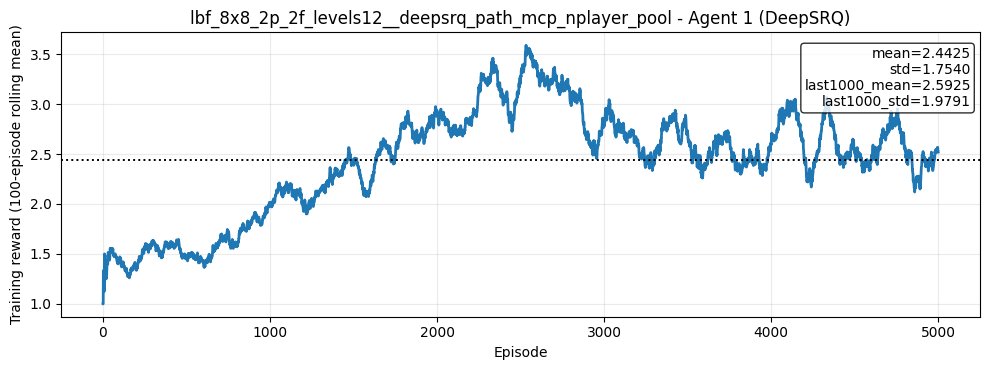

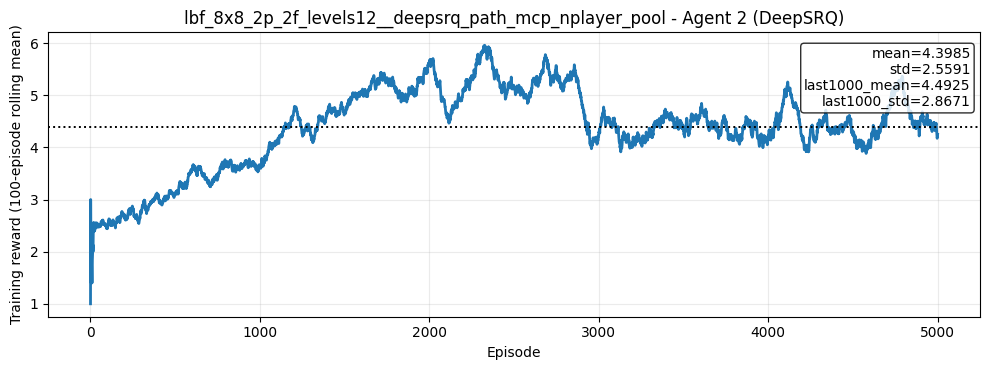

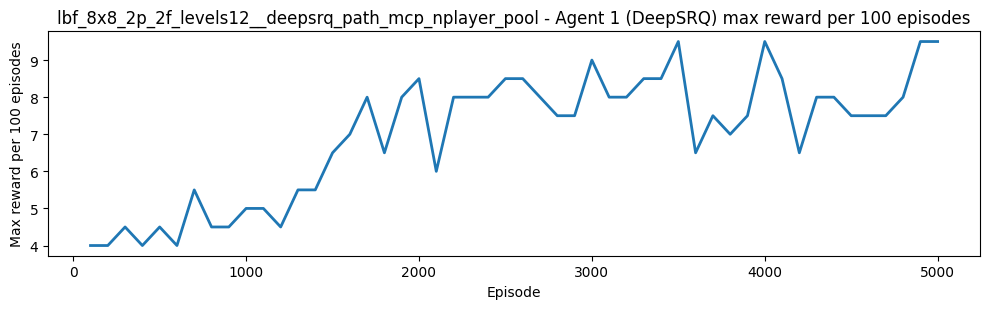

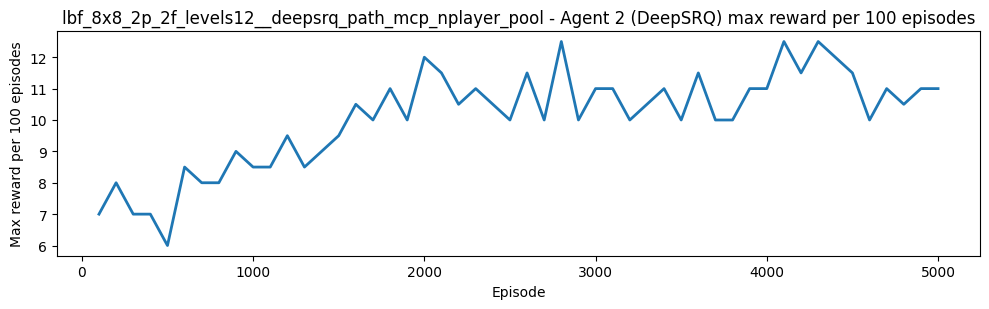

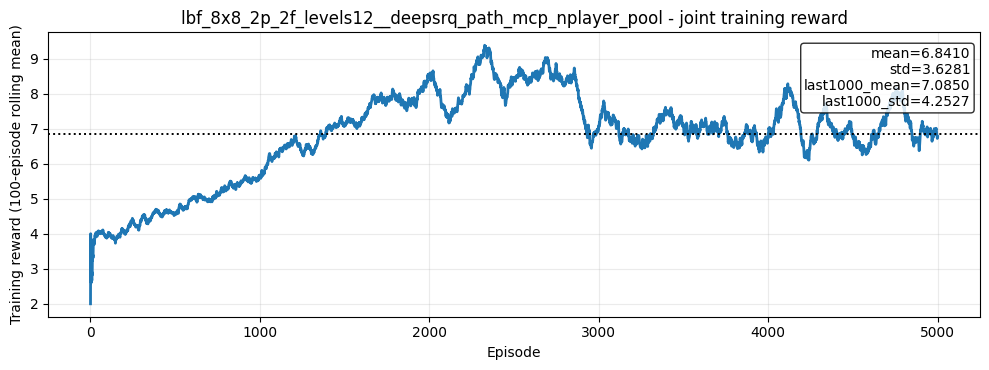

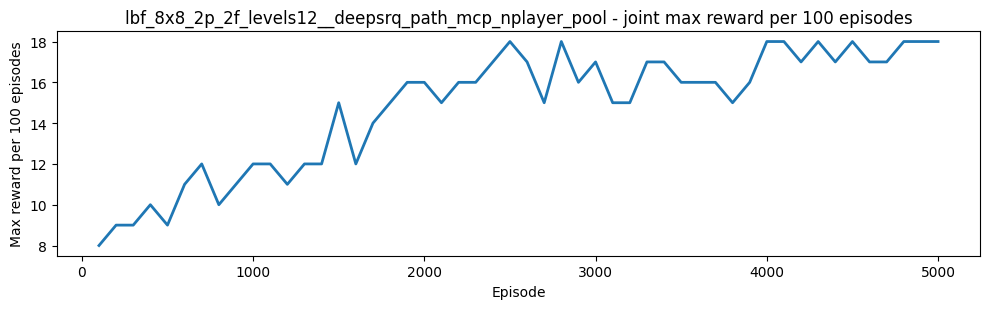

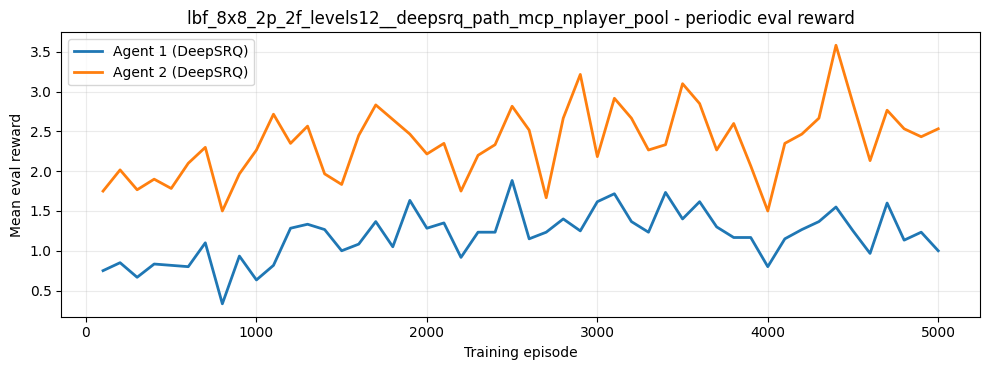

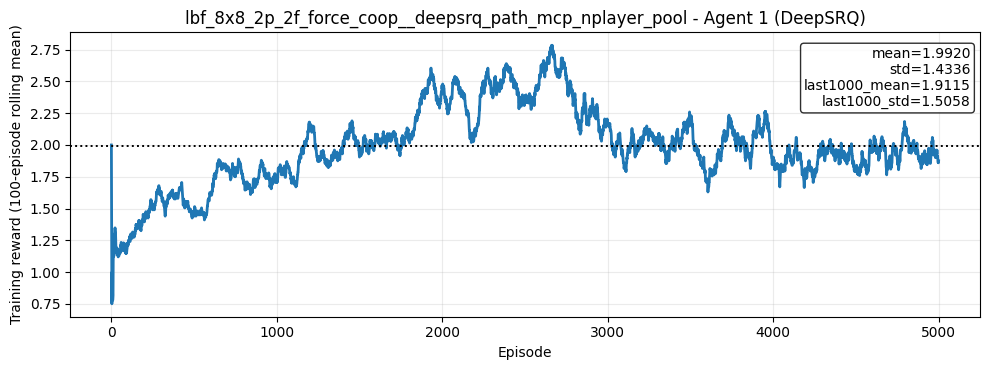

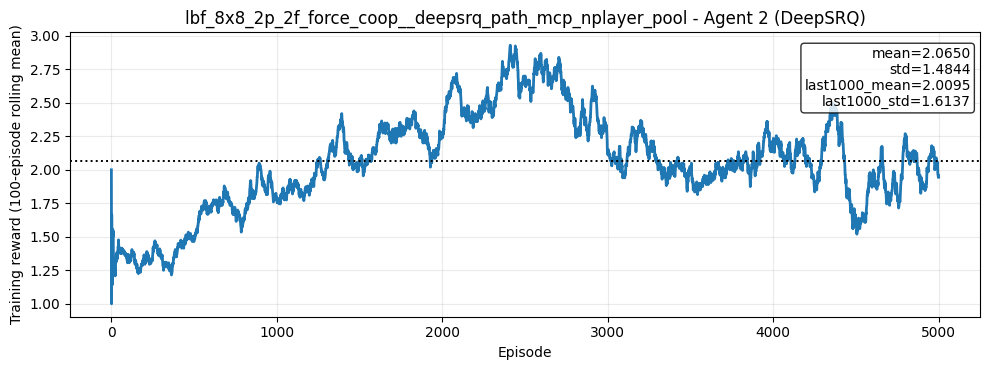

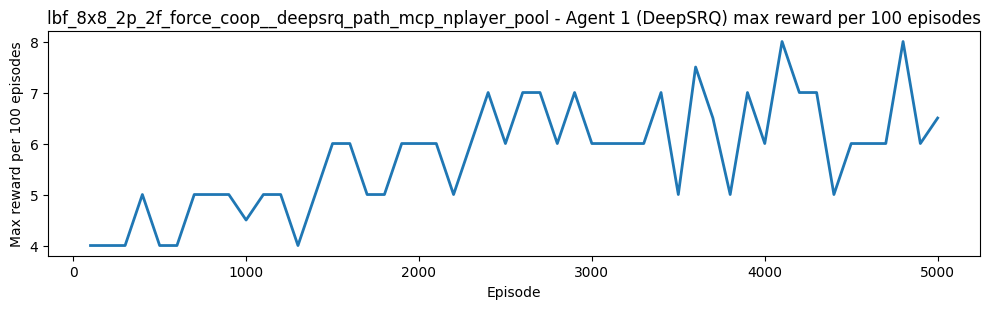

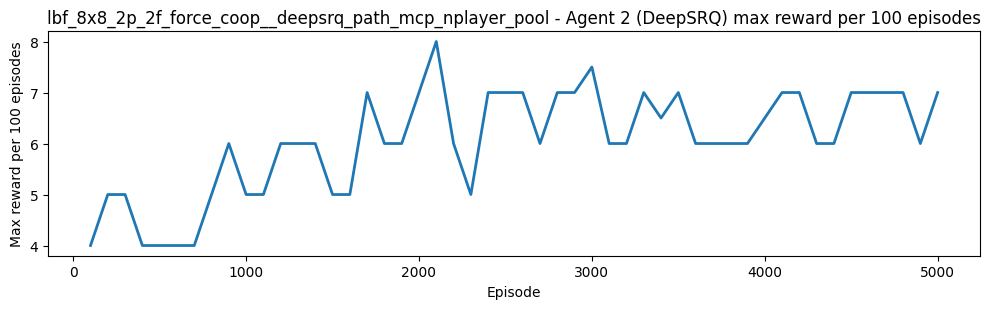

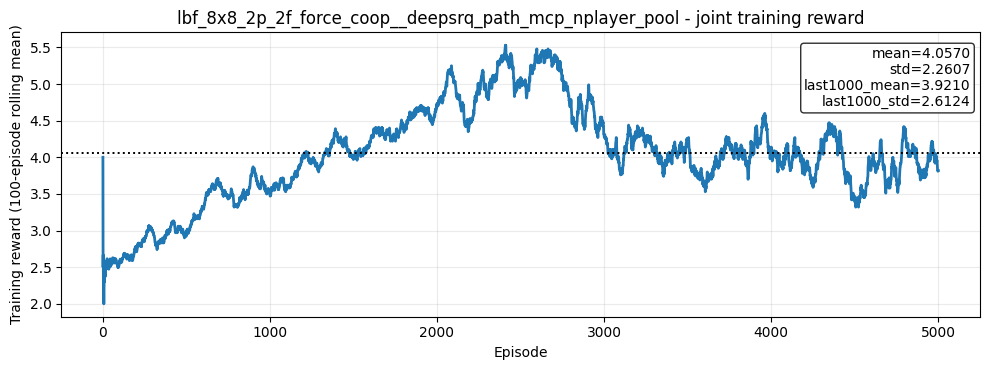

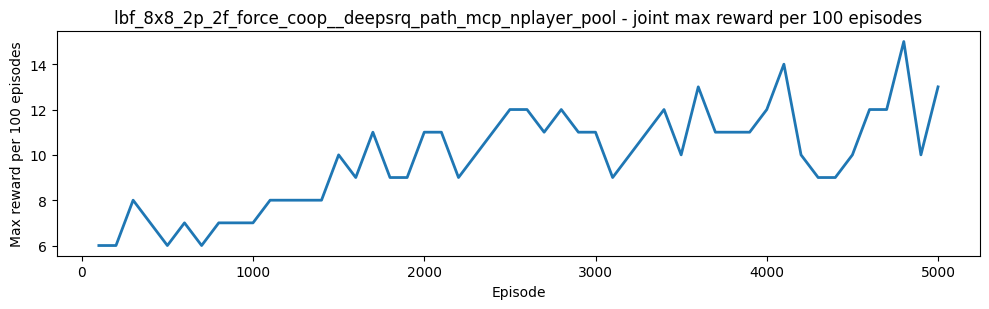

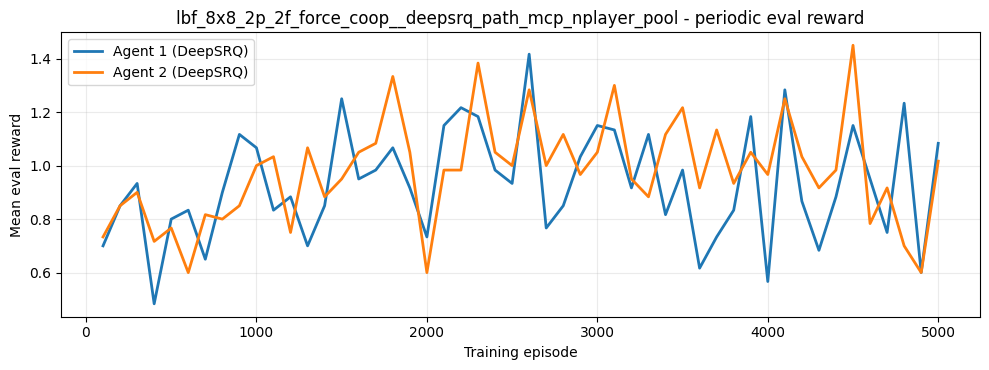

In [3]:
deep_srq_path_pool_eps_0_01_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.01,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 1,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
)
deep_srq_path_pool_eps_0_01_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_01_stats.values()))


## Robust epsilon 0.1

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.1 | schedule=constant | seed=2035 | num_envs=32 | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.1_constant:vec:   2%|▉                                          | 116/5000 [00:48<28:05,  2.90it/s]

[ep   100] train_joint=  3.6100 | eval_joint=  2.9000 | best_loss=0.021865 | latest_loss=0.057046 | solver_mean_ms=17.458


lbf:path_c_pool_eps0.1_constant:vec:   4%|█▊                                         | 215/5000 [01:31<27:44,  2.87it/s]

[ep   200] train_joint=  4.0800 | eval_joint=  3.0000 | best_loss=0.017796 | latest_loss=0.070992 | solver_mean_ms=17.199


...

[ep  4900] train_joint=  4.0700 | eval_joint=  2.1333 | best_loss=0.001583 | latest_loss=0.038802 | solver_mean_ms=22.091


lbf:path_c_pool_eps0.1_constant:vec: 100%|██████████████████████████████████████████| 5000/5000 [48:36<00:00,  3.45it/s]

[ep  5000] train_joint=  4.1500 | eval_joint=  2.1000 | best_loss=0.001583 | latest_loss=0.074862 | solver_mean_ms=22.103


lbf:path_c_pool_eps0.1_constant:vec: 100%|██████████████████████████████████████████| 5000/5000 [48:43<00:00,  1.71it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 2.08 | 1.53 | 2.09             | 1.67            | 5000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 2.09 | 1.52 | 2.09             | 1.71            | 5000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.1 ep=5000 best_loss=0.001582885393872857 latest_loss=0.0748624876141

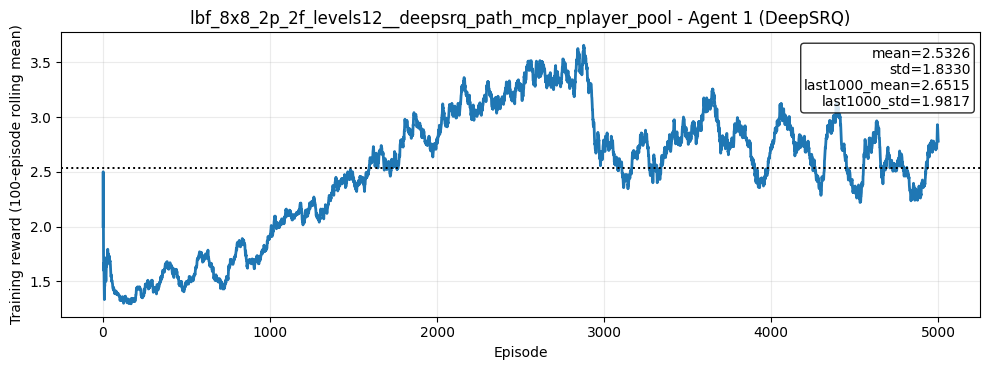

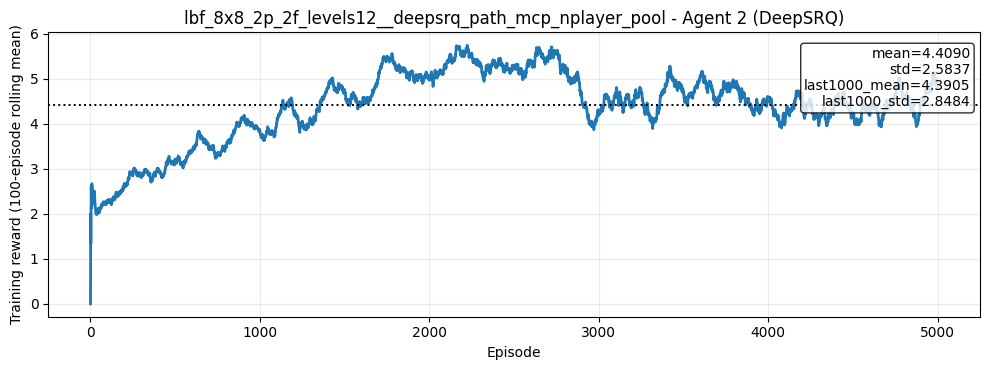

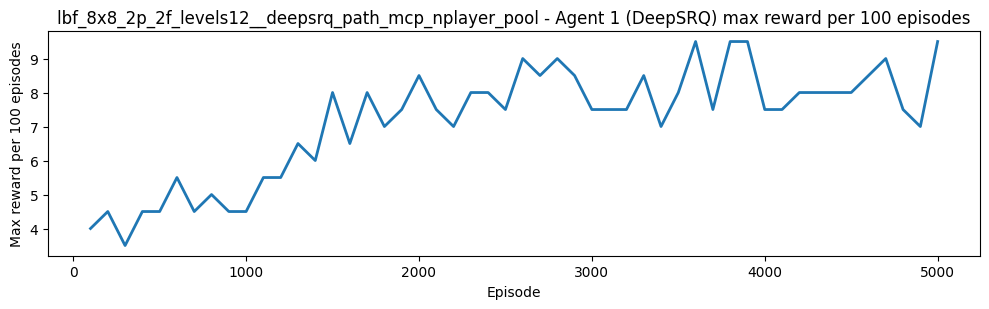

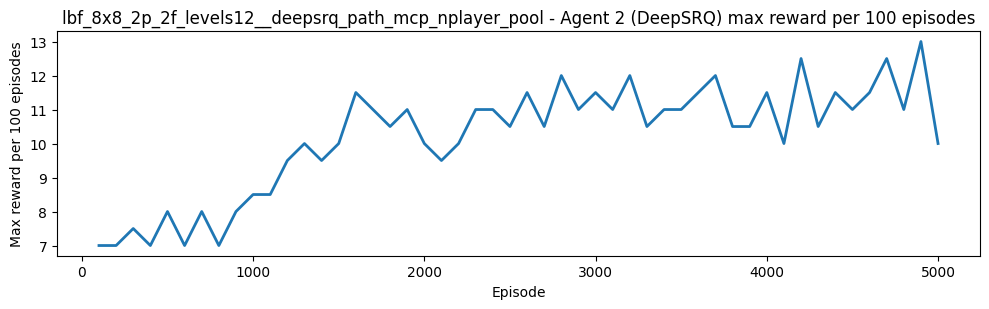

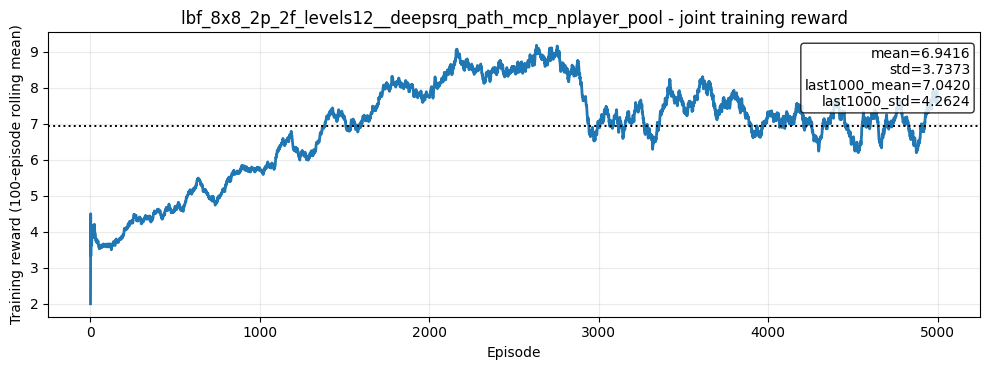

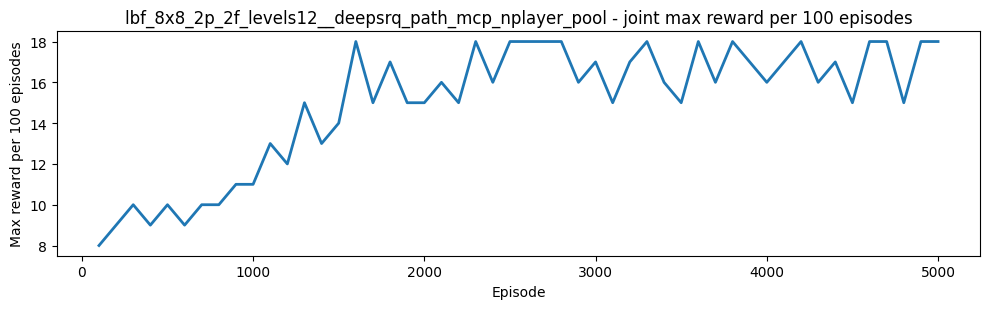

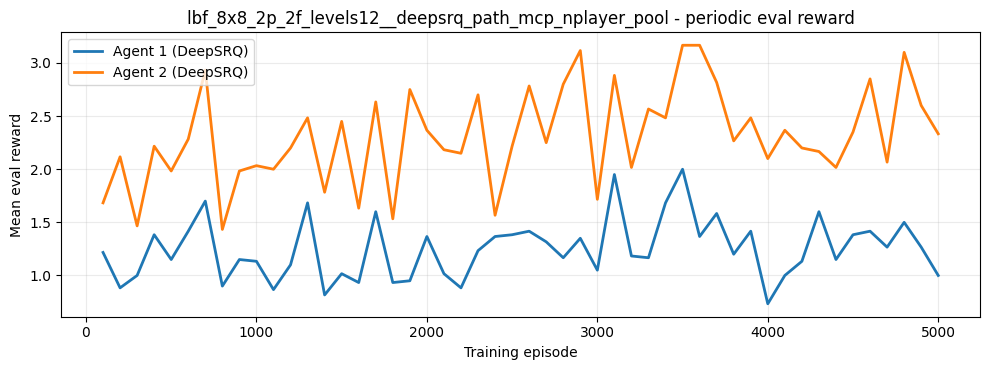

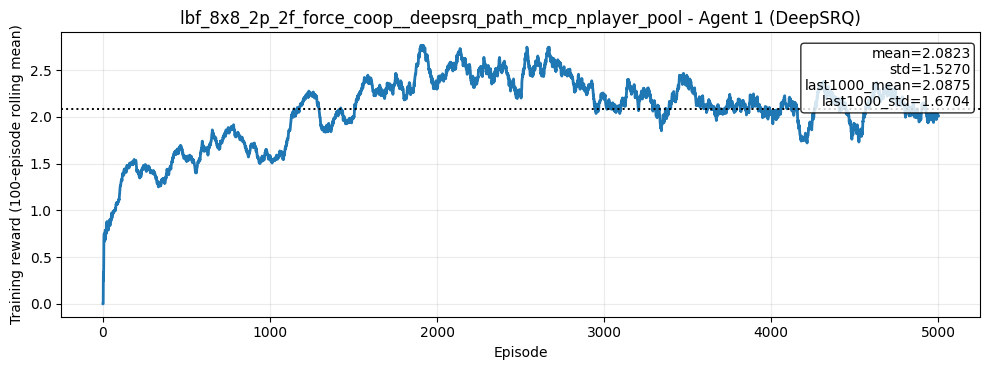

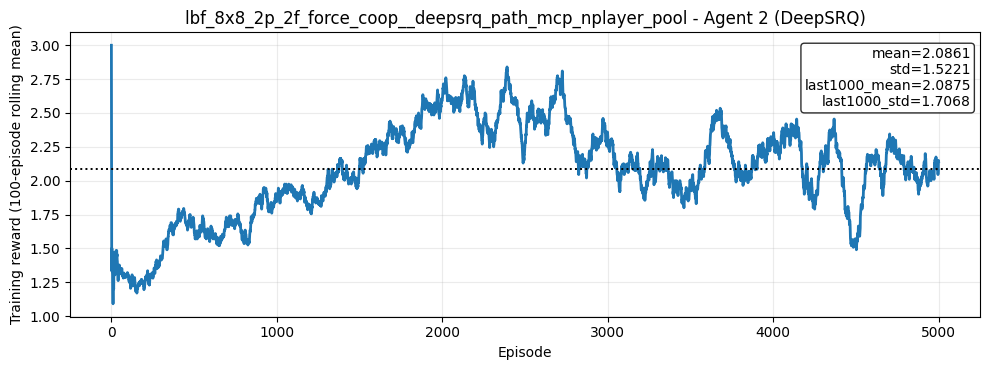

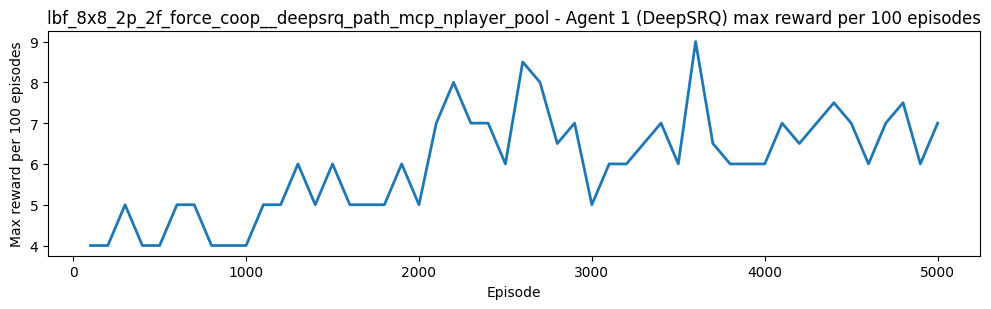

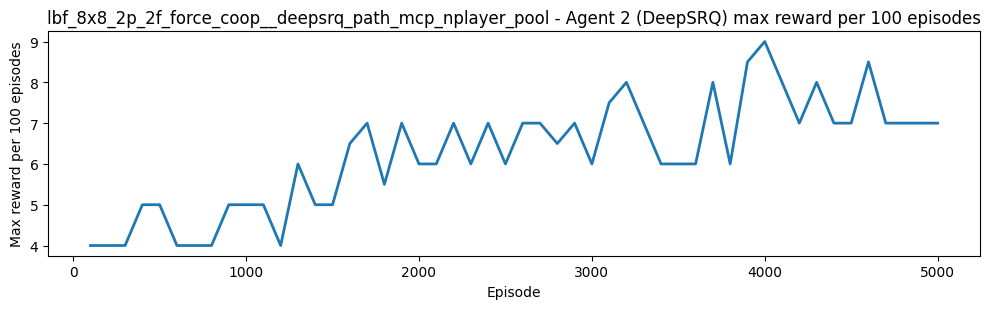

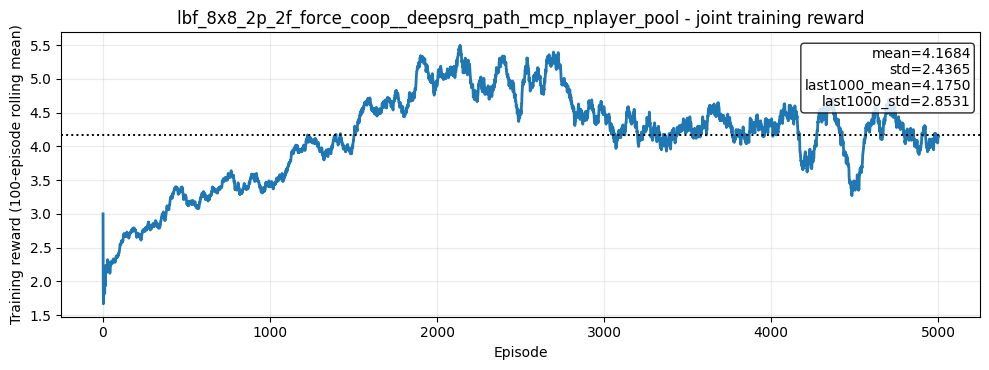

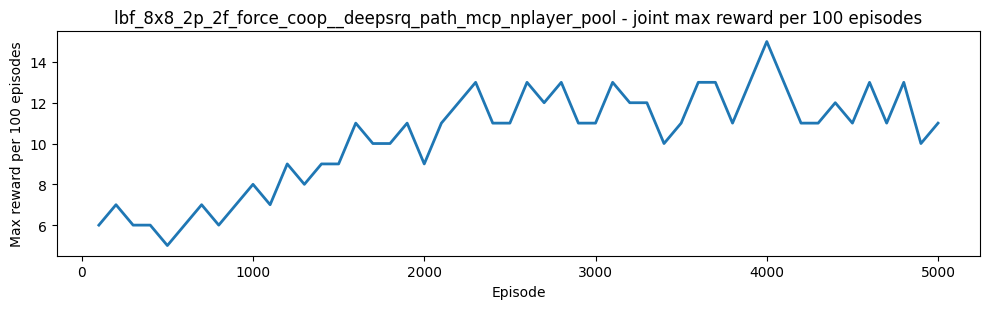

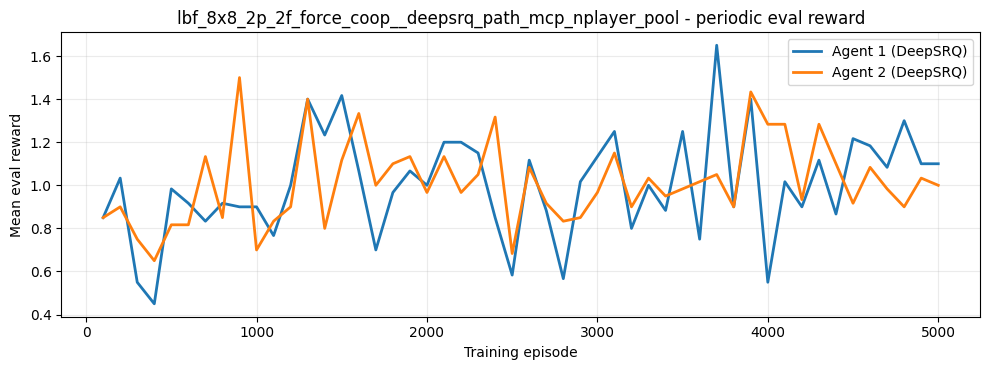

In [4]:
deep_srq_path_pool_eps_0_1_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.1,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 10,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
)
deep_srq_path_pool_eps_0_1_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_1_stats.values()))


## Robust epsilon 0.5

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=0.5 | schedule=constant | seed=2075 | num_envs=32 | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps0.5_constant:vec:   2%|▉                                          | 116/5000 [00:50<28:31,  2.85it/s]

[ep   100] train_joint=  3.7300 | eval_joint=  3.2667 | best_loss=0.024139 | latest_loss=0.087558 | solver_mean_ms=17.305


lbf:path_c_pool_eps0.5_constant:vec:   4%|█▊                                         | 216/5000 [01:32<28:37,  2.79it/s]

[ep   200] train_joint=  4.1700 | eval_joint=  3.2333 | best_loss=0.017500 | latest_loss=0.064280 | solver_mean_ms=16.892


...

[ep  4900] train_joint=  3.6100 | eval_joint=  2.6667 | best_loss=0.002533 | latest_loss=0.015915 | solver_mean_ms=22.415


lbf:path_c_pool_eps0.5_constant:vec: 100%|█████████████████████████████████████████▉| 4993/5000 [50:31<00:03,  1.95it/s]

[ep  5000] train_joint=  4.3700 | eval_joint=  2.4667 | best_loss=0.002533 | latest_loss=0.041774 | solver_mean_ms=22.453


lbf:path_c_pool_eps0.5_constant:vec: 100%|██████████████████████████████████████████| 5000/5000 [50:36<00:00,  1.65it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 2.03 | 1.47 | 1.99             | 1.60            | 5000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 2.11 | 1.48 | 2.07             | 1.61            | 5000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=0.5 ep=5000 best_loss=0.0025334355887025595 latest_loss=0.041773807257

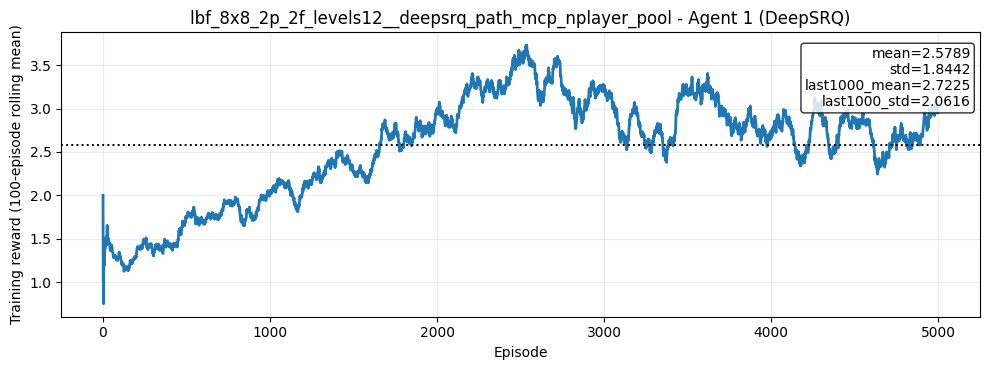

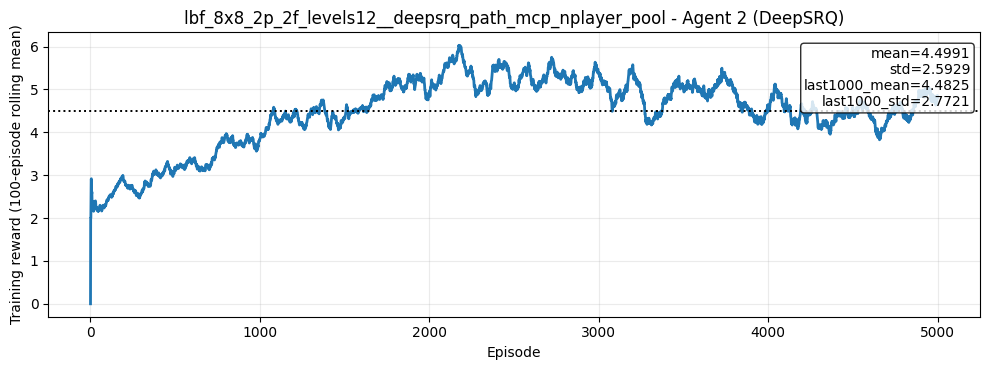

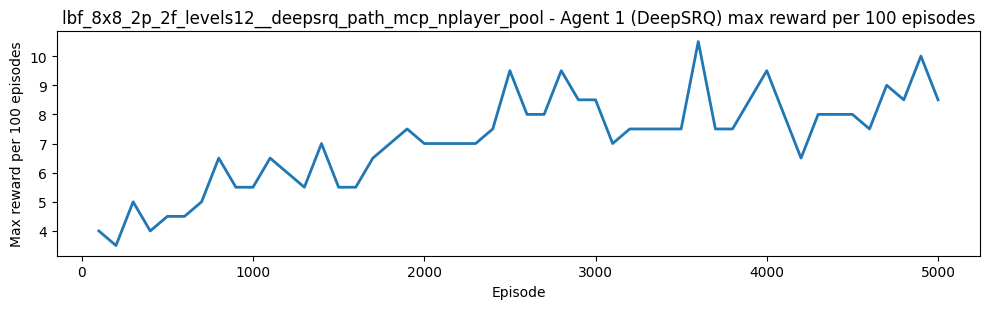

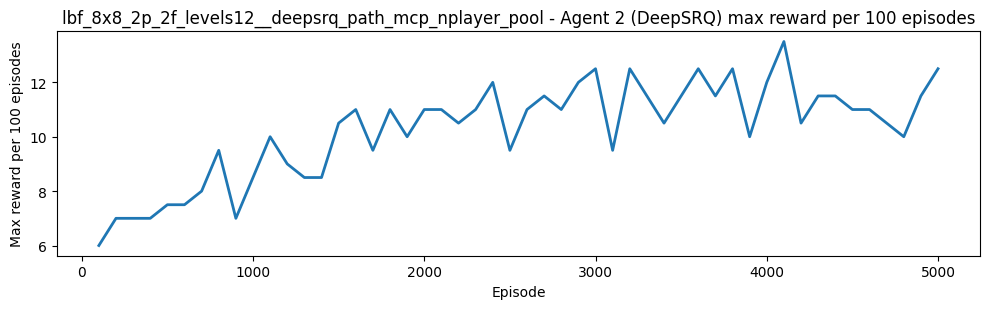

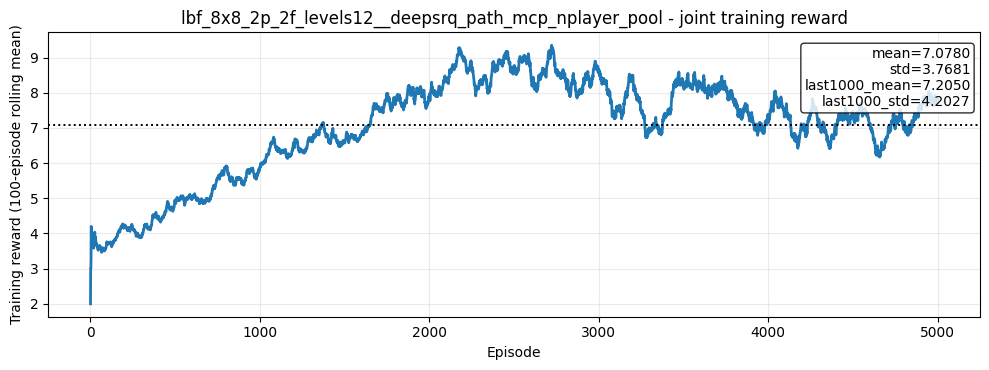

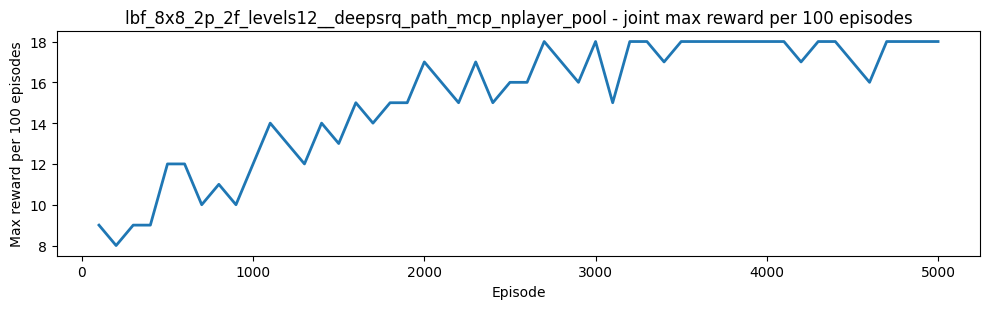

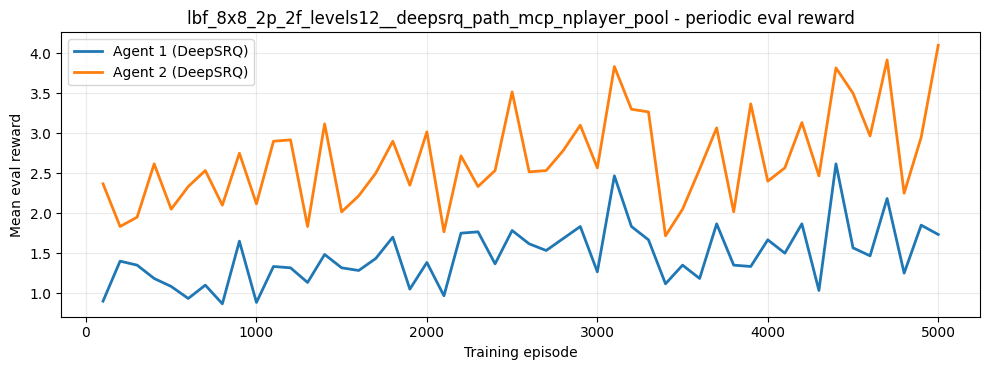

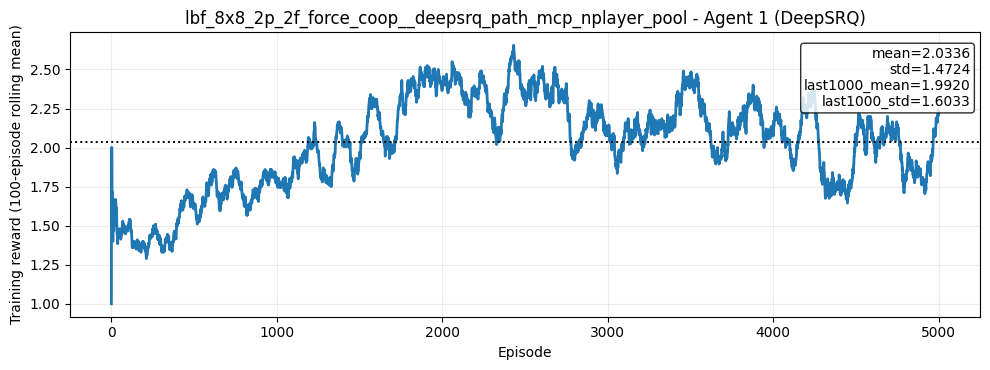

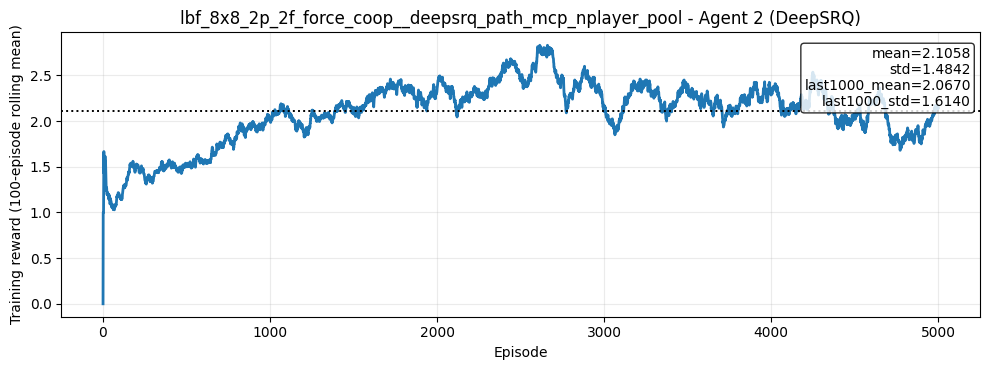

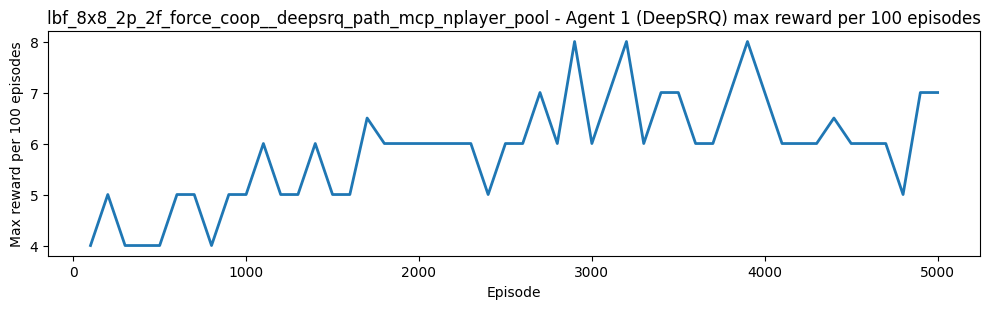

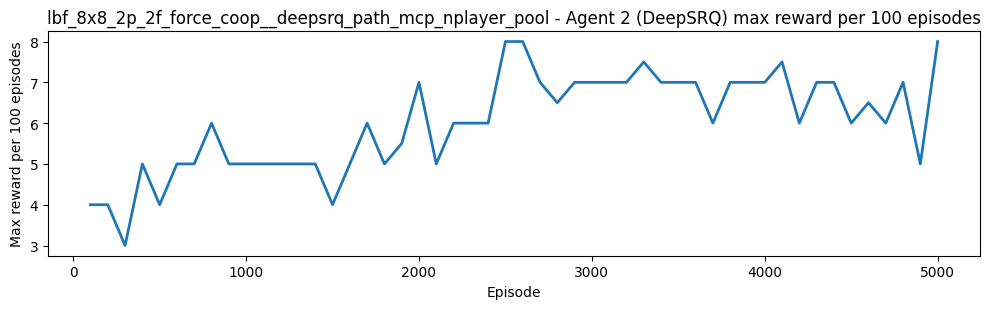

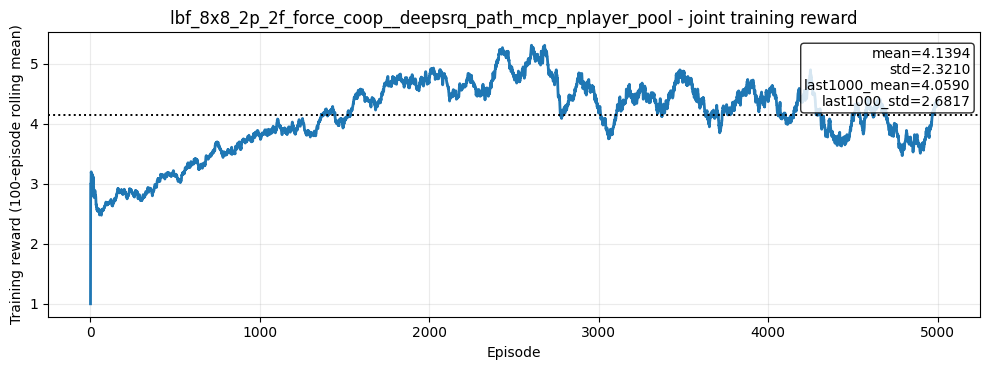

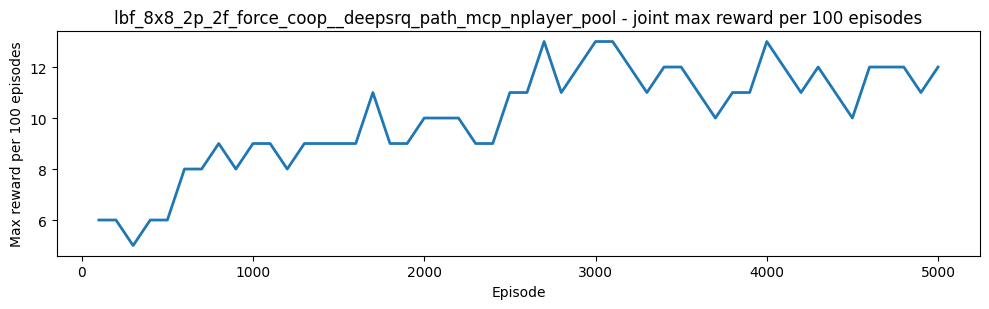

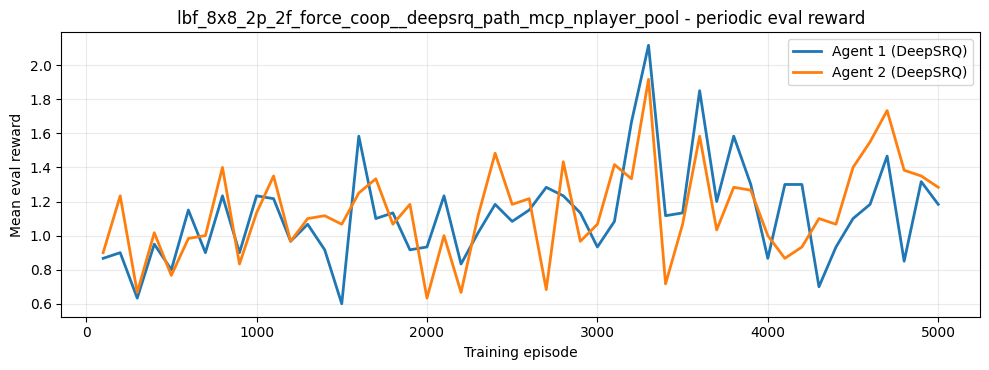

In [5]:
deep_srq_path_pool_eps_0_5_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    0.5,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 50,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
)
deep_srq_path_pool_eps_0_5_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_0_5_stats.values()))


## Robust epsilon 1

LBF DeepSRQ vectorized | players=2 | solver=path_c_pool | eps0=1 | schedule=constant | seed=2125 | num_envs=32 | agent_device=cuda | solver_device=n/a


lbf:path_c_pool_eps1_constant:vec:   2%|█                                            | 116/5000 [00:54<34:09,  2.38it/s]

[ep   100] train_joint=  3.7700 | eval_joint=  3.3000 | best_loss=0.023010 | latest_loss=0.082981 | solver_mean_ms=17.595


lbf:path_c_pool_eps1_constant:vec:   4%|█▉                                           | 220/5000 [01:39<30:31,  2.61it/s]

[ep   200] train_joint=  4.4400 | eval_joint=  4.7333 | best_loss=0.018604 | latest_loss=0.085301 | solver_mean_ms=17.111


...

[ep  4900] train_joint=  4.3000 | eval_joint=  2.8000 | best_loss=0.002404 | latest_loss=0.011508 | solver_mean_ms=21.312


lbf:path_c_pool_eps1_constant:vec: 100%|███████████████████████████████████████████▉| 4993/5000 [49:00<00:03,  2.28it/s]

[ep  5000] train_joint=  3.8800 | eval_joint=  3.1000 | best_loss=0.002404 | latest_loss=0.026699 | solver_mean_ms=21.321


lbf:path_c_pool_eps1_constant:vec: 100%|████████████████████████████████████████████| 5000/5000 [49:06<00:00,  1.70it/s]



Reward Summary
Scenario                                                                                                      | Pair              | Agent             | Mean | Std  | Mean (Last 1000) | Std (Last 1000) | Episodes
--------------------------------------------------------------------------------------------------------------+-------------------+-------------------+------+------+------------------+-----------------+---------
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 1 (DeepSRQ) | 1.96 | 1.39 | 2.03             | 1.50            | 5000    
2 level-1 agents, 8x8 grid, 10 foods (5 level-1, 5 level-2), full sight, forced cooperation, 50-step episodes | DeepSRQ self-play | Agent 2 (DeepSRQ) | 2.04 | 1.40 | 2.11             | 1.49            | 5000    
DeepSRQ PATH pool lbf_8x8_2p_2f_force_coop solver=path_c_pool eps=1.0 ep=5000 best_loss=0.0024036329705268145 latest_loss=0.026699163019

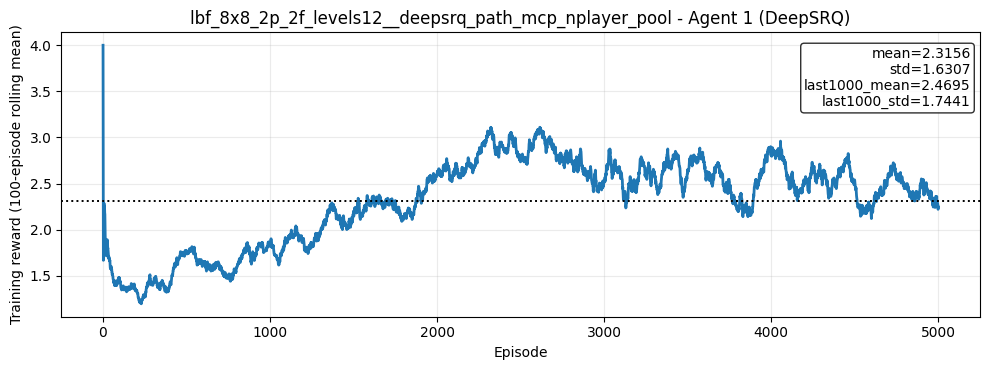

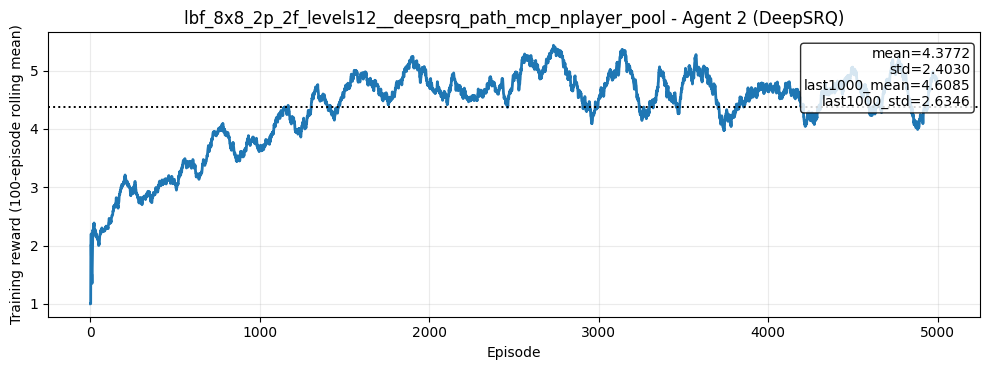

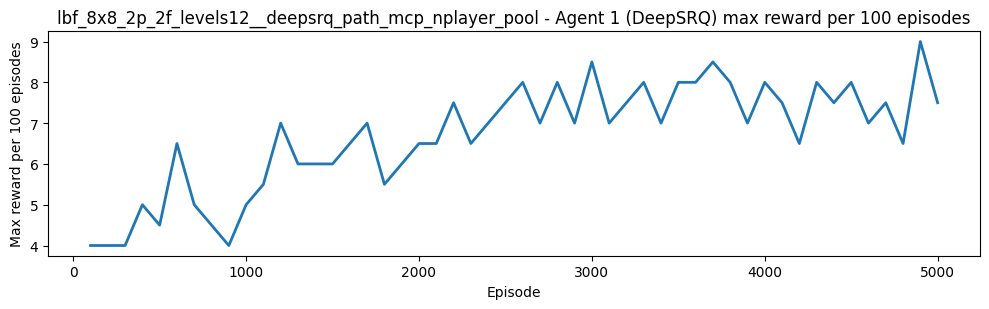

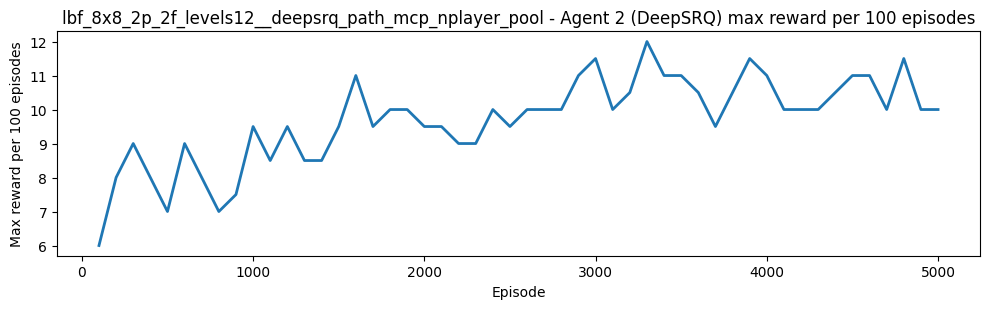

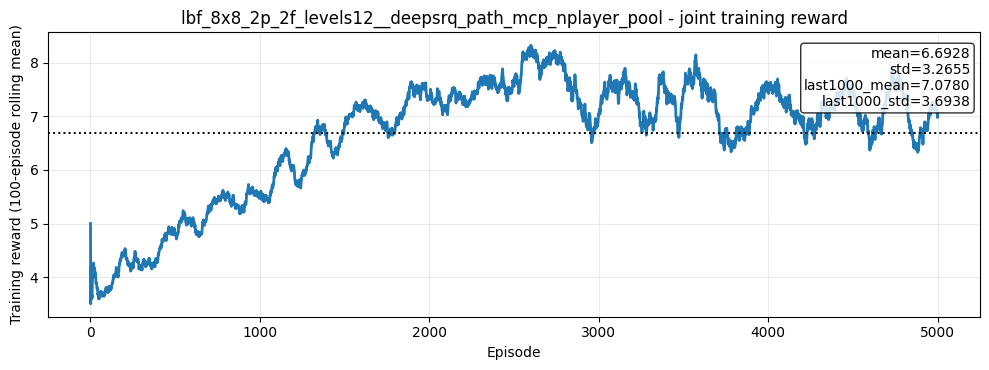

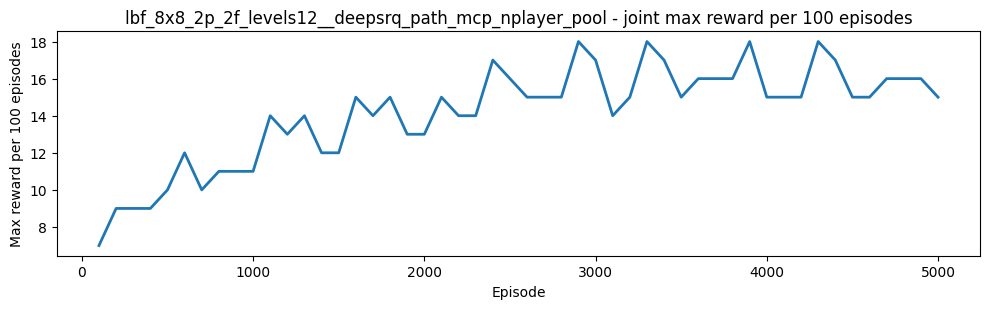

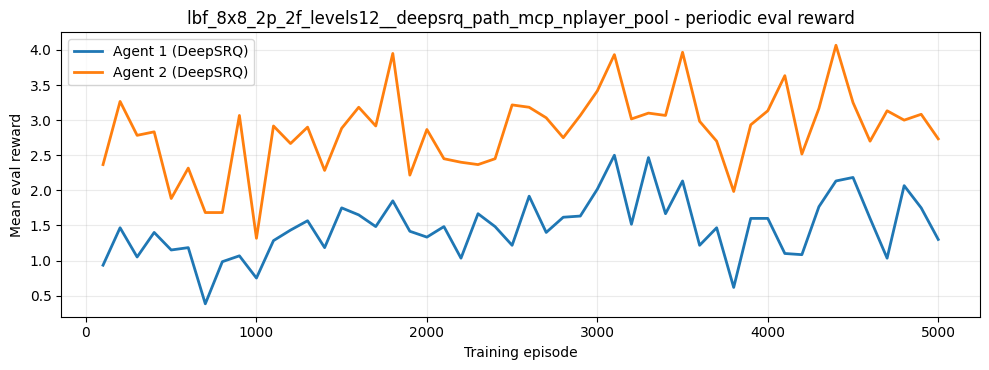

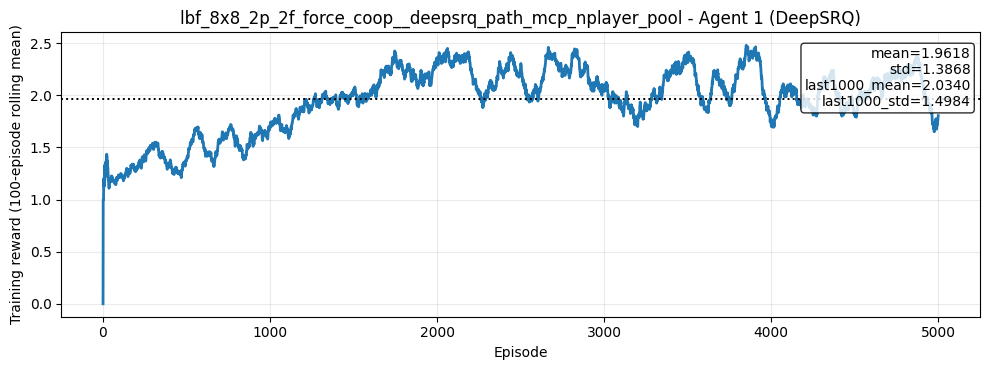

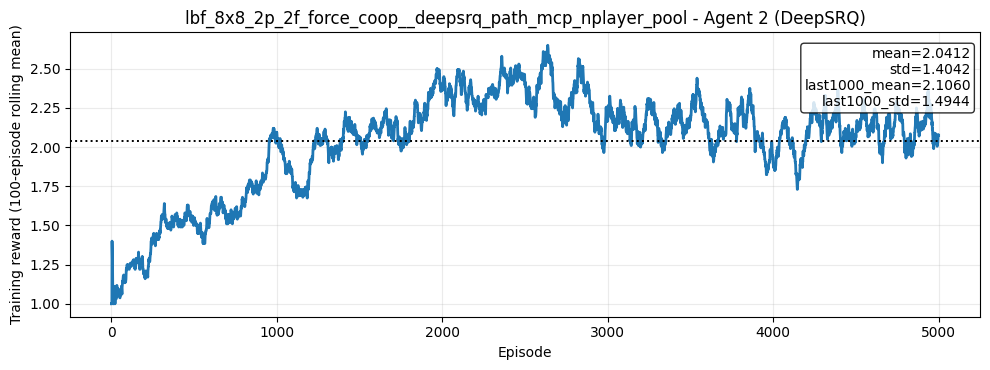

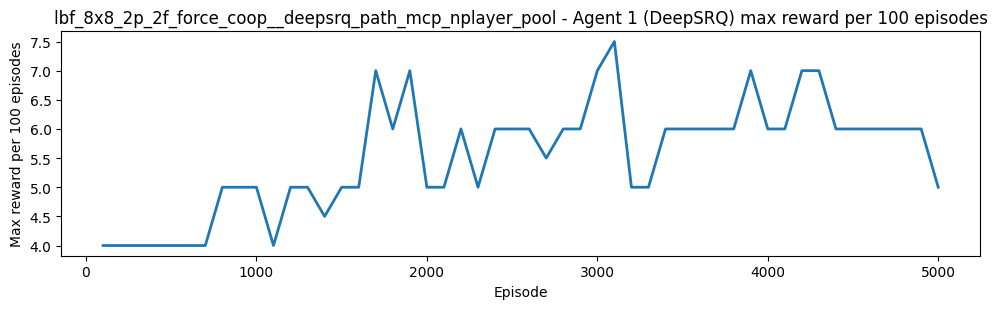

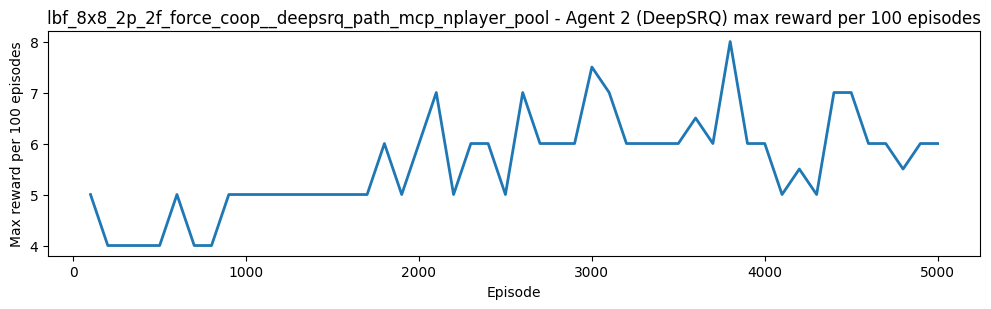

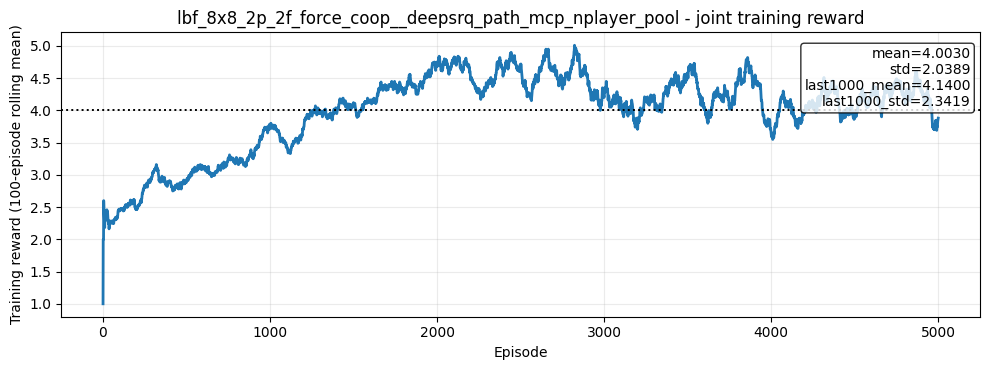

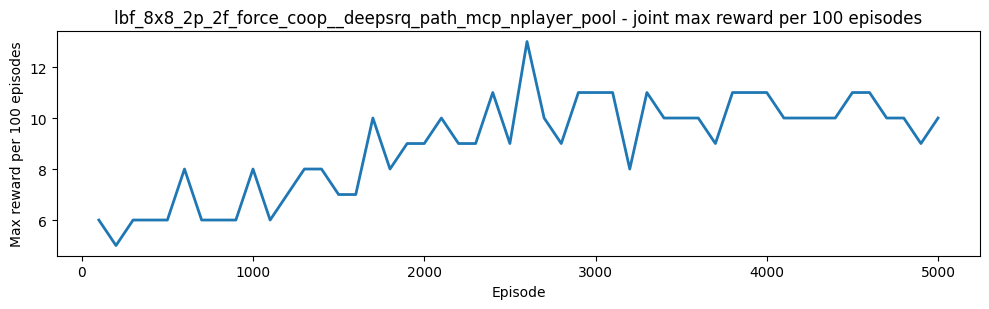

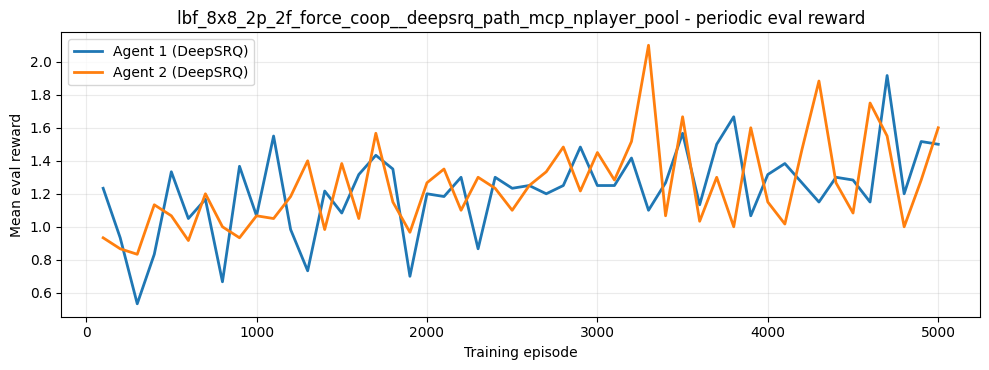

In [6]:
deep_srq_path_pool_eps_1_0_stats = train_deepsrq_path_mcp_pool_for_epsilon(
    1.0,
    n_episodes=N_EPISODES,
    scenarios=SCENARIOS,
    base_seed=BASE_SEED + 100,
    use_gpu=USE_GPU,
    eval_interval=EVAL_INTERVAL,
    eval_episodes=EVAL_EPISODES_DURING_TRAINING,
    sre_solver_workers=SRE_SOLVER_WORKERS,
    num_envs=NUM_ENVS,
    eval_num_envs=EVAL_NUM_ENVS,
    nplayer_solver_name=PATH_POOL_NPLAYER_SOLVER,
    hyperparameter_overrides=PATH_MCP_HYPERPARAMETER_OVERRIDES,
    repo_root=REPO_ROOT,
    skip_existing=SKIP_EXISTING_TRAINING,
)
deep_srq_path_pool_eps_1_0_training_figs = display_training_reward_plots(newly_trained_records(deep_srq_path_pool_eps_1_0_stats.values()))
